In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def frameBuilder(path="./live-data"):
    cols = pd.read_csv("header.csv").columns.tolist()
    data = Path(path).glob("trade-*.csv")
    df = pd.concat(
    (pd.read_csv(f, skiprows=1, header=None, names=cols) for f in data),
    ignore_index=True)
    return df

Pnl: -6.519109999999989
Optimal entry: 48
Entries: 365; wins: 357; losses: 8; pnl: 20.825680000000002 


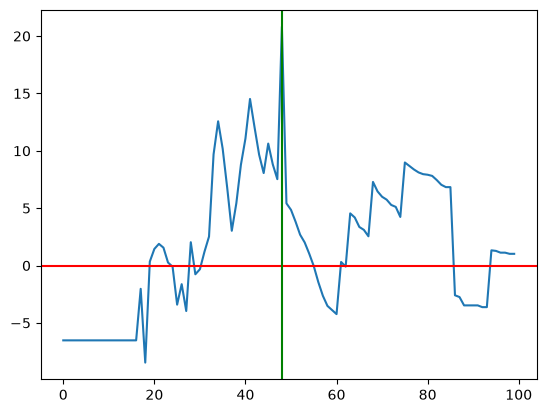

In [42]:
df = frameBuilder()

print(f"Pnl: {df.realized_pnl.sum()}")

fig = plt.figure()
x = np.arange(0,100)
y = np.zeros(100)
for i in range(100):
    y[i] = df[abs(df.price_diff_from_entry)>=x[i]].realized_pnl.sum()
optimal_entry = np.argmax(y)

plt.plot(x, y)
plt.axhline(y=0, color='r')
plt.axvline(x=optimal_entry, color='g')


print(f"Optimal entry: {optimal_entry}")
optimal = df[abs(df.price_diff_from_entry) >= optimal_entry]
print(f"Entries: {len(optimal)}; wins: {len(optimal[optimal.won==1])}; losses: {len(optimal[optimal.won==0])}; pnl: {optimal.realized_pnl.sum()} ")


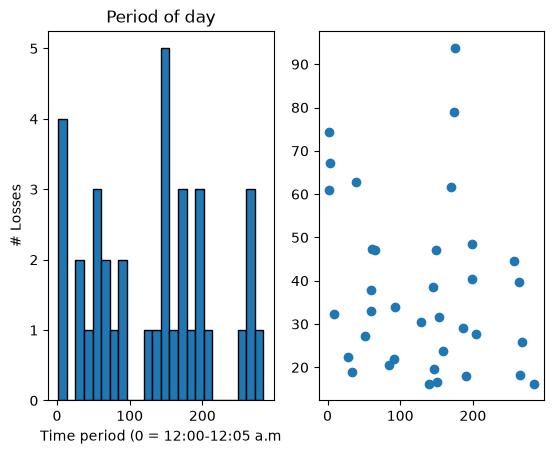

In [31]:
# What went wrong
losses = df[df.won==0]

# display(losses)

fig, ax = plt.subplots(1, 2)

# Period of day
ax[0].hist(losses.period_of_day, bins=24, edgecolor='black')
ax[0].set_title("Period of day")
ax[0].set_ylabel("# Losses")
ax[0].set_xlabel("Time period (0 = 12:00-12:05 a.m")

# Price difference
ax[1].scatter(losses.period_of_day, abs(losses.price_diff_from_entry))